In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
data=pd.read_csv("student_dropout_dataset_v3.csv")
data

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


In [3]:
df=data.copy()
df

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


In [4]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [5]:
df.tail()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [6]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [7]:
df.shape

(10000, 19)

In [8]:
df.info

<bound method DataFrame.info of       Student_ID   Age  Gender  Family_Income Internet_Access  \
0              1  22.1    Male        25000.0             Yes   
1              2  20.7    Male        25000.0             Yes   
2              3  22.4    Male        40183.0             Yes   
3              4  24.4    Male            NaN             Yes   
4              5  20.5  Female        25319.0             Yes   
...          ...   ...     ...            ...             ...   
9995        9996  23.9  Female        42286.0              No   
9996        9997  17.0  Female        61103.0             Yes   
9997        9998  19.4    Male        25000.0             Yes   
9998        9999  22.1  Female        40302.0             Yes   
9999       10000  22.4  Female        76796.0             Yes   

      Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                    3.36             86.1                      2   
1                    4.30             68.0       

In [9]:
df.isna().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [10]:
df=df.drop('Student_ID',axis=1)
df

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


In [11]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

(array([8.016e+03, 1.084e+03, 2.970e+02, 7.000e+01, 1.800e+01, 1.100e+01,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([ 25000. ,  54160.1,  83320.2, 112480.3, 141640.4, 170800.5,
        199960.6, 229120.7, 258280.8, 287440.9, 316601. ]),
 <BarContainer object of 10 artists>)

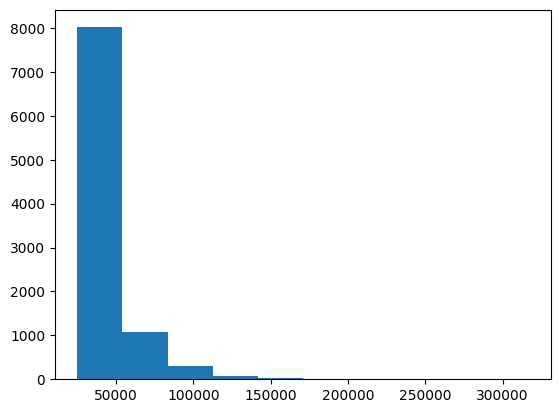

In [12]:
plt.hist(df['Family_Income'])

In [13]:
df['Family_Income']=df['Family_Income'].fillna(df['Family_Income'].median())

(array([ 193.,  587., 1343., 2311., 2337., 1644.,  804.,  222.,   49.,
          10.]),
 array([0.5  , 1.348, 2.196, 3.044, 3.892, 4.74 , 5.588, 6.436, 7.284,
        8.132, 8.98 ]),
 <BarContainer object of 10 artists>)

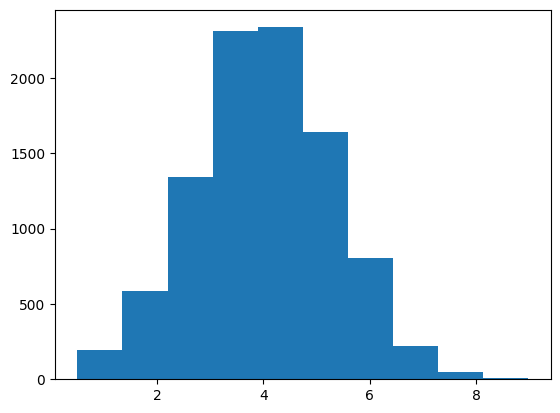

In [14]:
plt.hist(df['Study_Hours_per_Day'])

In [15]:
df['Study_Hours_per_Day']=df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean())

(array([ 195.,  389.,  834., 1417., 1748., 1892., 1452.,  930.,  422.,
         221.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

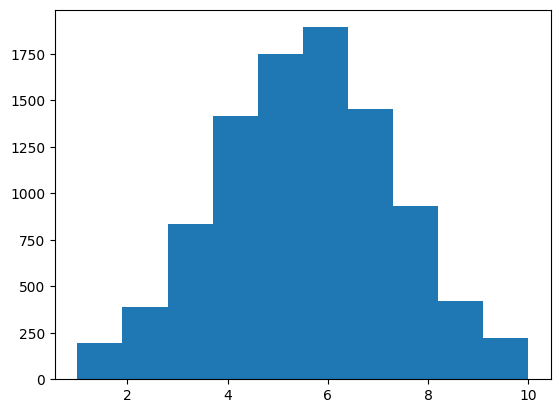

In [16]:
plt.hist(df['Stress_Index'])

In [17]:
df['Stress_Index']=df['Stress_Index'].fillna(df['Stress_Index'].mean())

In [18]:
df['Parental_Education']=df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

In [19]:
df.isna().sum()

Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [20]:
df

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.68,1.32,1.32,Year 1,Arts,Master,0
3,24.4,Male,29740.5,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.78,1.77,1.77,Year 1,CS,High School,1
4,20.5,Female,25319.0,Yes,4.190000,75.7,1,23.0,No,No,7.000000,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,Female,42286.0,No,4.620000,92.0,0,10.0,Yes,Yes,5.500000,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,17.0,Female,61103.0,Yes,2.870000,75.2,3,32.4,No,Yes,6.700000,3.09,3.09,3.09,Year 1,Business,Master,1
9997,19.4,Male,25000.0,Yes,4.730000,74.9,4,25.4,No,No,3.500000,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,22.1,Female,40302.0,Yes,5.850000,74.2,1,5.0,No,Yes,6.200000,3.35,3.34,3.34,Year 1,CS,High School,0


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [23]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

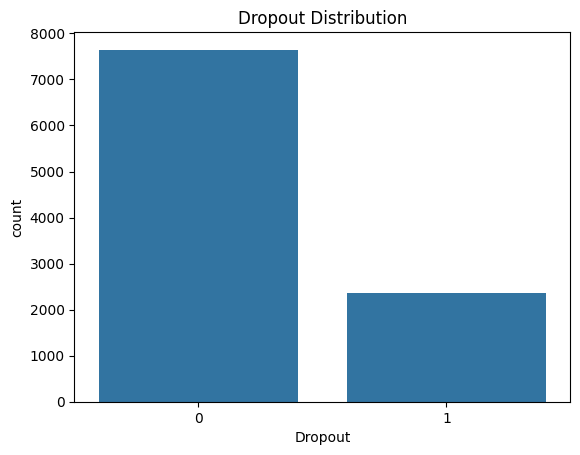

In [24]:
sns.countplot(x='Dropout', data=df)
plt.title("Dropout Distribution")
plt.show()

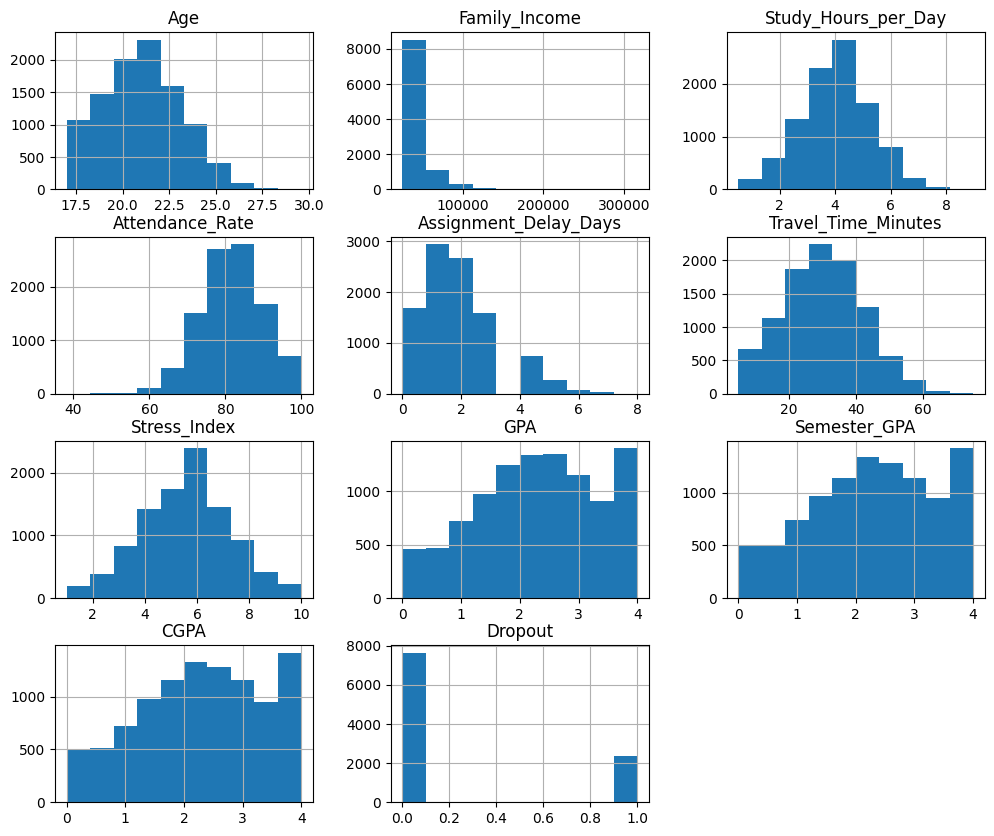

In [25]:
df.hist(figsize=(12,10))
plt.show()

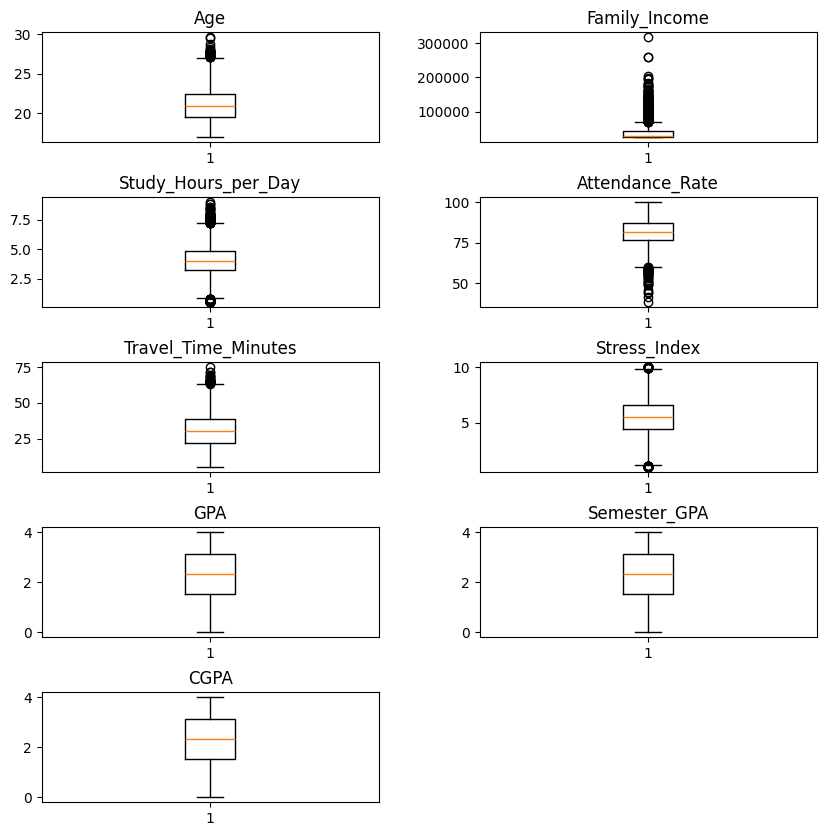

In [26]:
outlier_columns=['Age','Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Travel_Time_Minutes','Stress_Index','GPA', 'Semester_GPA', 'CGPA']
plt.figure(figsize=(10,10))
i=1
for col in outlier_columns:
    plt.subplots_adjust(wspace=0.3,hspace=0.5)
    plt.subplot(5,2,i)
    plt.boxplot(df[col])
    plt.title(col)
    i+=1

# PreProcessing

In [27]:
le_gender=LabelEncoder()
le_internet=LabelEncoder()
le_partime=LabelEncoder()
le_scholar=LabelEncoder()
le_sem=LabelEncoder()
le_dept=LabelEncoder()
le_pnt_edu=LabelEncoder()

df['Gender']=le_gender.fit_transform(df['Gender'])
df['Internet_Access']=le_internet.fit_transform(df['Internet_Access'])
df['Part_Time_Job']=le_partime.fit_transform(df['Part_Time_Job'])
df['Scholarship']=le_scholar.fit_transform(df['Scholarship'])
df['Semester']=le_sem.fit_transform(df['Semester'])
df['Department']=le_dept.fit_transform(df['Department'])
df['Parental_Education']=le_pnt_edu.fit_transform(df['Parental_Education'])

In [28]:
df.dtypes

Age                      float64
Gender                     int64
Family_Income            float64
Internet_Access            int64
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job              int64
Scholarship                int64
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                   int64
Department                 int64
Parental_Education         int64
Dropout                    int64
dtype: object

In [29]:
corr=df.corr()
corr

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
Age,1.000000,-0.006871,0.008041,0.007835,0.001680,0.011307,0.012405,-0.014714,-0.008779,1.344384e-02,-2.327994e-02,-0.010184,-0.009947,-0.010478,-0.010530,0.009364,-0.016862,0.007585
Gender,-0.006871,1.000000,0.004654,-0.009042,0.010382,-0.015404,-0.013346,-0.000133,0.009553,5.707366e-04,-1.418491e-03,-0.003944,-0.004297,-0.004251,-0.002748,-0.005686,-0.014716,-0.007265
Family_Income,0.008041,0.004654,1.000000,-0.006084,0.003850,0.003801,0.007394,0.017330,0.019459,2.522795e-02,-2.132301e-02,-0.002187,0.001445,0.000506,0.009014,-0.010716,0.005358,-0.010324
Internet_Access,0.007835,-0.009042,-0.006084,1.000000,-0.003291,-0.002868,0.004400,0.000975,-0.004415,6.506783e-03,-1.225655e-02,0.003245,0.006085,0.005816,0.027105,0.009748,-0.005405,-0.043205
Study_Hours_per_Day,0.001680,0.010382,0.003850,-0.003291,1.000000,-0.014909,0.000253,0.011320,-0.015657,-6.650639e-03,8.643154e-03,0.209379,0.202431,0.202795,0.005210,0.002344,0.013787,-0.087177
Attendance_Rate,0.011307,-0.015404,0.003801,-0.002868,-0.014909,1.000000,-0.009601,0.015214,-0.016246,9.067552e-03,-1.481913e-02,0.206739,0.197346,0.197620,-0.009932,-0.019583,-0.012515,-0.163539
Assignment_Delay_Days,0.012405,-0.013346,0.007394,0.004400,0.000253,-0.009601,1.000000,-0.000300,0.007288,7.052925e-03,8.346556e-03,-0.029449,-0.024166,-0.024580,-0.003387,-0.006999,-0.000733,0.082327
Travel_Time_Minutes,-0.014714,-0.000133,0.017330,0.000975,0.011320,0.015214,-0.000300,1.000000,0.000641,1.050349e-02,2.938287e-03,0.013925,0.011190,0.011841,-0.002430,-0.000126,-0.007177,0.028080
Part_Time_Job,-0.008779,0.009553,0.019459,-0.004415,-0.015657,-0.016246,0.007288,0.000641,1.000000,-3.439457e-04,-6.490804e-03,-0.002277,-0.003921,-0.004276,0.005069,0.015618,0.008262,0.036781
Scholarship,0.013444,0.000571,0.025228,0.006507,-0.006651,0.009068,0.007053,0.010503,-0.000344,1.000000e+00,-8.969178e-08,0.006794,0.007976,0.007441,-0.005805,-0.002465,-0.009287,-0.006661


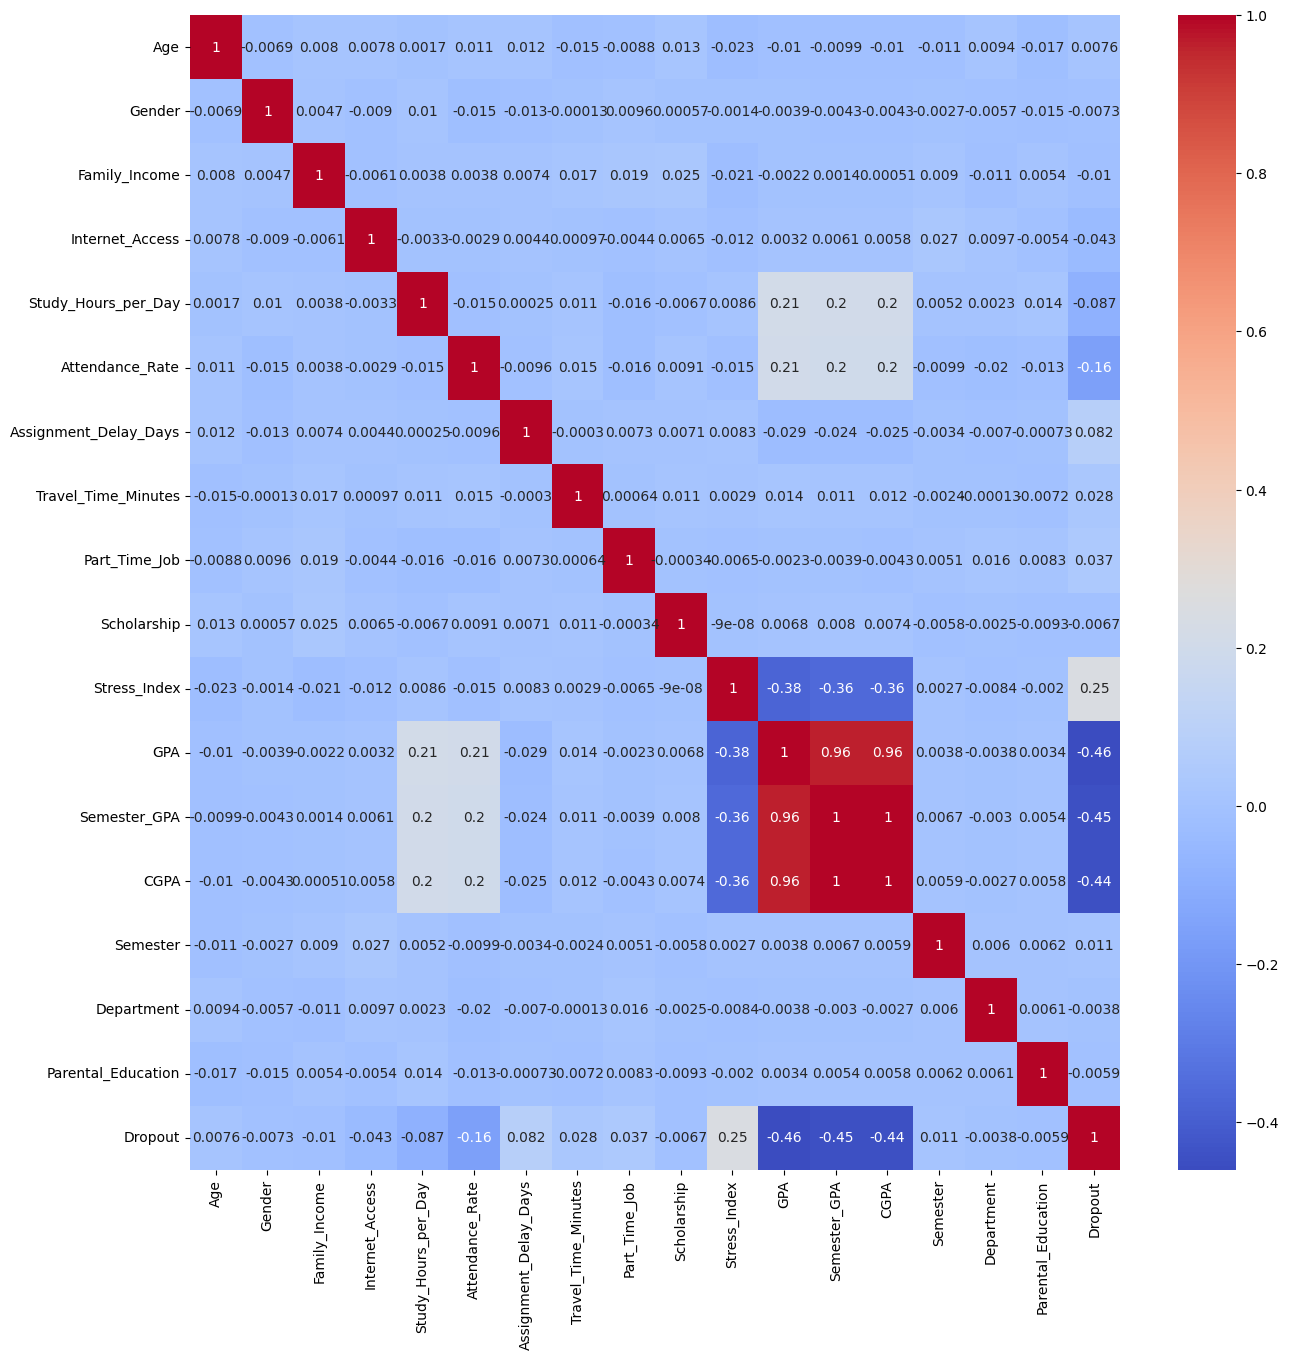

In [30]:
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [31]:
x=df.drop('Dropout',axis=1)
x

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education
0,22.1,1,25000.0,1,3.360000,86.1,2,20.4,1,0,5.500000,0.96,0.90,0.90,0,0,1
1,20.7,1,25000.0,1,4.300000,68.0,2,44.0,0,0,6.800000,1.28,1.20,1.19,2,3,0
2,22.4,1,40183.0,1,4.400000,70.9,0,48.9,1,0,5.500000,1.68,1.32,1.32,0,0,2
3,24.4,1,29740.5,1,4.014592,82.2,2,38.6,0,0,5.507147,1.78,1.77,1.77,0,2,1
4,20.5,0,25319.0,1,4.190000,75.7,1,23.0,0,0,7.000000,1.48,0.91,0.87,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,0,42286.0,0,4.620000,92.0,0,10.0,1,1,5.500000,1.60,0.99,0.97,1,0,0
9996,17.0,0,61103.0,1,2.870000,75.2,3,32.4,0,1,6.700000,3.09,3.09,3.09,0,1,2
9997,19.4,1,25000.0,1,4.730000,74.9,4,25.4,0,0,3.500000,3.45,3.37,3.43,3,1,0
9998,22.1,0,40302.0,1,5.850000,74.2,1,5.0,0,1,6.200000,3.35,3.34,3.34,0,2,1


In [32]:
y=df[['Dropout']]
y

,Dropout
0,0
1,1
2,0
3,1
4,0
...,...
9995,0
9996,1
9997,0
9998,0


# Model Building

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [34]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [35]:
dtc=DecisionTreeClassifier()
dtc.fit(x_train_scaled,y_train)
y_pred_dtc=dtc.predict(x_test_scaled)
dtcm=dtc.score(x_train_scaled,y_train)
dtca=accuracy_score(y_test,y_pred_dtc)
print("DTC train score:",dtcm)
print("DTC accuracy:",dtca)

DTC train score: 1.0
DTC accuracy: 0.7255


In [36]:
rfc=RandomForestClassifier()
rfc.fit(x_train_scaled,y_train)
y_pred_rfc=rfc.predict(x_test_scaled)
rfcm=rfc.score(x_train_scaled,y_train)
rfca=accuracy_score(y_test,y_pred_rfc)
print("rfC train score:",rfcm)
print("rfC accuracy:",rfca)

rfC train score: 1.0
rfC accuracy: 0.8035


In [37]:
knc=KNeighborsClassifier()
knc.fit(x_train_scaled,y_train)
y_pred_knc=knc.predict(x_test_scaled)
kncm=knc.score(x_train_scaled,y_train)
knca=accuracy_score(y_test,y_pred_knc)
print("knC train score:",kncm)
print("knC accuracy:",knca)

knC train score: 0.841375
knC accuracy: 0.787


In [38]:
svc=SVC()
svc.fit(x_train_scaled,y_train)
y_pred_svc=svc.predict(x_test_scaled)
svcm=svc.score(x_train_scaled,y_train)
svca=accuracy_score(y_test,y_pred_svc)
print("svC train score:",svcm)
print("svC accuracy:",svca)

svC train score: 0.83
svC accuracy: 0.8165


In [39]:
adbc=AdaBoostClassifier()
adbc.fit(x_train_scaled,y_train)
y_pred_adbc=adbc.predict(x_test_scaled)
adbcm=adbc.score(x_train_scaled,y_train)
adbca=accuracy_score(y_test,y_pred_adbc)
print("adbC train score:",adbcm)
print("adbC accuracy:",adbca)

adbC train score: 0.80875
adbC accuracy: 0.8085


In [40]:
gbc=GradientBoostingClassifier()
gbc.fit(x_train_scaled,y_train)
y_pred_gbc=gbc.predict(x_test_scaled)
gbcm=gbc.score(x_train_scaled,y_train)
gbca=accuracy_score(y_test,y_pred_gbc)
print("gbC train score:",gbcm)
print("gbC accuracy:",gbca)

gbC train score: 0.829
gbC accuracy: 0.8065


In [41]:
xgbc=XGBClassifier()
xgbc.fit(x_train_scaled,y_train)
y_pred_xgbc=xgbc.predict(x_test_scaled)
xgbcm=gbc.score(x_train_scaled,y_train)
xgbca=accuracy_score(y_test,y_pred_xgbc)
print("xgbC train score:",xgbcm)
print("xgbC accuracy:",xgbca)

xgbC train score: 0.829
xgbC accuracy: 0.7875


In [42]:
dfr=pd.DataFrame()
dfr["Model"]=pd.Series(["DTC","RFC","KNC","SVC","AD BOOST","GD BOOST","XG BOOST"])
dfr["Test accuracry"]=pd.Series([dtca,rfca,knca,svca,adbca,gbca,xgbca])
dfr["Train accuracry"]=pd.Series([dtcm,rfcm,kncm,svcm,adbcm,gbcm,xgbcm])
dfr

,Model,Test accuracry,Train accuracry
0,DTC,0.7255,1.000000
1,RFC,0.8035,1.000000
2,KNC,0.7870,0.841375
3,SVC,0.8165,0.830000
4,AD BOOST,0.8085,0.808750
5,GD BOOST,0.8065,0.829000
6,XG BOOST,0.7875,0.829000


# Smote

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)

In [44]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [45]:
y_train.value_counts()

Dropout
0          6117
1          1883
Name: count, dtype: int64

In [46]:
sme=SMOTE()
x_train_sme,y_train_sme=sme.fit_resample(x_train_scaled,y_train)

In [47]:
y_train_sme.value_counts()

Dropout
0          6117
1          6117
Name: count, dtype: int64

In [48]:
dtc_sm=DecisionTreeClassifier()
dtc_sm.fit(x_train_sme,y_train_sme)
y_pred_dtc_sm=dtc_sm.predict(x_test_scaled)
dtcm_sm=dtc_sm.score(x_train_sme,y_train_sme)
dtca_sm=accuracy_score(y_test,y_pred_dtc_sm)
print("DTC train score:",dtcm_sm)
print("DTC accuracy:",dtca_sm)

DTC train score: 1.0
DTC accuracy: 0.719


In [49]:
rfc_sm=RandomForestClassifier()
rfc_sm.fit(x_train_sme,y_train_sme)
y_pred_rfc_sm=rfc.predict(x_test_scaled)
rfcm_sm=rfc_sm.score(x_train_sme,y_train_sme)
rfca_sm=accuracy_score(y_test,y_pred_rfc_sm)
print("rfC train score:",rfcm_sm)
print("rfC accuracy:",rfca_sm)

rfC train score: 1.0
rfC accuracy: 0.944


In [50]:
knc_sm=KNeighborsClassifier()
knc_sm.fit(x_train_sme,y_train_sme)
y_pred_knc_sm=knc_sm.predict(x_test_scaled)
kncm_sm=knc_sm.score(x_train_sme,y_train_sme)
knca_sm=accuracy_score(y_test,y_pred_knc_sm)
print("knC train score:",kncm_sm)
print("knC accuracy:",knca_sm)

knC train score: 0.8694621546509727
knC accuracy: 0.6625


In [51]:
svc_sm=SVC()
svc_sm.fit(x_train_sme,y_train_sme)
y_pred_svc_sm=svc_sm.predict(x_test_scaled)
svcm_sm=svc_sm.score(x_train_sme,y_train_sme)
svca_sm=accuracy_score(y_test,y_pred_svc_sm)
print("svC train score:",svcm_sm)
print("svC accuracy:",svca_sm)

svC train score: 0.8244237371260422
svC accuracy: 0.7345


In [52]:
adbc_sm=AdaBoostClassifier()
adbc_sm.fit(x_train_sme,y_train_sme)
y_pred_adbc_sm=adbc_sm.predict(x_test_scaled)
adbcm_sm=adbc_sm.score(x_train_sme,y_train_sme)
adbca_sm=accuracy_score(y_test,y_pred_adbc_sm)
print("adbC train score:",adbcm_sm)
print("adbC accuracy:",adbca_sm)

adbC train score: 0.7920549288867091
adbC accuracy: 0.742


In [53]:
gbc_sm=GradientBoostingClassifier()
gbc_sm.fit(x_train_sme,y_train_sme)
y_pred_gbc_sm=gbc_sm.predict(x_test_scaled)
gbcm_sm=gbc_sm.score(x_train_sme,y_train_sme)
gbca_sm=accuracy_score(y_test,y_pred_gbc_sm)
print("gbC train score:",gbcm_sm)
print("gbC accuracy:",gbca_sm)

gbC train score: 0.8645577897662253
gbC accuracy: 0.792


In [54]:
xgbc_sm=XGBClassifier()
xgbc_sm.fit(x_train_sme,y_train_sme)
y_pred_xgbc_sm=xgbc_sm.predict(x_test_scaled)
xgbcm_sm=gbc_sm.score(x_train_sme,y_train_sme)
xgbca_sm=accuracy_score(y_test,y_pred_xgbc_sm)
print("xgbC train score:",xgbcm_sm)
print("xgbC accuracy:",xgbca_sm)

xgbC train score: 0.8645577897662253
xgbC accuracy: 0.779


In [55]:
dfr1=pd.DataFrame()
dfr1["Model"]=pd.Series(["DTC_sm","RFC_sm","KNC_sm","SVC_sm","AD BOOST_sm","GD BOOST_sm","XG BOOST_sm"])
dfr1["Test accuracry"]=pd.Series([dtca_sm,rfca_sm,knca_sm,svca_sm,adbca_sm,gbca_sm,xgbca_sm])
dfr1["Train accuracry"]=pd.Series([dtcm_sm,rfcm_sm,kncm_sm,svcm_sm,adbcm_sm,gbcm_sm,xgbcm_sm])
dfr1

,Model,Test accuracry,Train accuracry
0,DTC_sm,0.7190,1.000000
1,RFC_sm,0.9440,1.000000
2,KNC_sm,0.6625,0.869462
3,SVC_sm,0.7345,0.824424
4,AD BOOST_sm,0.7420,0.792055
5,GD BOOST_sm,0.7920,0.864558
6,XG BOOST_sm,0.7790,0.864558


In [56]:
dfr

,Model,Test accuracry,Train accuracry
0,DTC,0.7255,1.000000
1,RFC,0.8035,1.000000
2,KNC,0.7870,0.841375
3,SVC,0.8165,0.830000
4,AD BOOST,0.8085,0.808750
5,GD BOOST,0.8065,0.829000
6,XG BOOST,0.7875,0.829000


# Hypertuning

In [57]:
dtc_params={
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dtc_grid=GridSearchCV(
    DecisionTreeClassifier(),
    dtc_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)

dtc_grid.fit(x_train_sme,y_train_sme)
y_pred_dtc_ht=dtc_grid.predict(x_test_scaled)
dtc_htt=dtc_grid.score(x_train_sme,y_train_sme)
dtc_hta=accuracy_score(y_test,y_pred_dtc_ht)
print("Best params DTC:",dtc_grid.best_params_)
print("DTC train score:",dtc_htt)
print("DTC accuracy:",dtc_hta)

Best params DTC: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
DTC train score: 1.0
DTC accuracy: 0.704


In [58]:
rfc_params={
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10],
    "min_samples_split":[2,5]
}

rfc_grid=GridSearchCV(
    RandomForestClassifier(),
    rfc_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)

rfc_grid.fit(x_train_sme,y_train_sme)
y_pred_rfc_ht=rfc_grid.predict(x_test_scaled)
rfc_htt=rfc_grid.score(x_train_sme,y_train_sme)
rfc_hta=accuracy_score(y_test,y_pred_rfc_ht)
print("Best params RFC:",rfc_grid.best_params_)
print("RFC train score:",rfc_htt)
print("RFC accuracy:",rfc_hta)

Best params RFC: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RFC train score: 1.0
RFC accuracy: 0.7795


In [59]:
knc_params={
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

knc_grid=GridSearchCV(
    KNeighborsClassifier(),
    knc_params,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    scoring="accuracy"
)

knc_grid.fit(x_train_sme,y_train_sme)
y_pred_knc_ht=knc_grid.predict(x_test_scaled)
knc_htt=knc_grid.score(x_train_sme,y_train_sme)
knc_hta=accuracy_score(y_test,y_pred_knc_ht)
print("Best params KNC:",knc_grid.best_params_)
print("KNC train score:",knc_htt)
print("KNC accuracy:",knc_hta)

Best params KNC: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
KNC train score: 1.0
KNC accuracy: 0.694


In [60]:
svc_params={
    "C":[1,10,],
    "kernel":["linear","rbf"],
    "gamma":["scaler",0.01]
}

svc_grid=GridSearchCV(
    SVC(),
    svc_params,
    cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42),
    scoring="accuracy",
    n_jobs=-1
)
svc_grid.fit(x_train_sme,y_train_sme)
y_pred_svc_ht=svc_grid.predict(x_test_scaled)
svc_htt=svc_grid.score(x_train_sme,y_train_sme)
svc_hta=accuracy_score(y_test,y_pred_svc_ht)
print("Best params SVC:",svc_grid.best_params_)
print("SVC train score:",svc_htt)
print("SVC accuracy:",svc_hta)

Best params SVC: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC train score: 0.7864149092692496
SVC accuracy: 0.7345


In [61]:
adbc_params={
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

adbc_grid=GridSearchCV(
    AdaBoostClassifier(),
    adbc_params,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    scoring="accuracy"
)
adbc_grid.fit(x_train_sme,y_train_sme)
y_pred_adbc_ht=adbc_grid.predict(x_test_scaled)
adbc_htt=adbc_grid.score(x_train_sme,y_train_sme)
adbc_hta=accuracy_score(y_test,y_pred_adbc_ht)
print("Best params ADBC:",adbc_grid.best_params_)
print("ADBC train score:",adbc_htt)
print("ADBC accuracy:",adbc_hta)

Best params ADBC: {'learning_rate': 1.0, 'n_estimators': 300}
ADBC train score: 0.856465587706392
ADBC accuracy: 0.7995


In [62]:
gbc_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

gbc_grid = GridSearchCV(
    GradientBoostingClassifier(),
    gbc_params,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1
)
gbc_grid.fit(x_train_sme,y_train_sme)
y_pred_gbc_ht=gbc_grid.predict(x_test_scaled)
gbc_htt=gbc_grid.score(x_train_sme,y_train_sme)
gbc_hta=accuracy_score(y_test,y_pred_gbc_ht)
print("Best params GBC:",gbc_grid.best_params_)
print("GBC train score:",gbc_htt)
print("GBC accuracy:",gbc_hta)

Best params GBC: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 200}
GBC train score: 0.9016674840608141
GBC accuracy: 0.798


In [63]:
xgbc_params={
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

xgbc_grid=GridSearchCV(
    XGBClassifier(),
    xgbc_params,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    scoring="accuracy"
)
xgbc_grid.fit(x_train_sme,y_train_sme)
y_pred_xgbc_ht=xgbc_grid.predict(x_test_scaled)
xgbc_htt=xgbc_grid.score(x_train_sme,y_train_sme)
xgbc_hta=accuracy_score(y_test,y_pred_xgbc_ht)
print("Best params XGBC:",xgbc_grid.best_params_)
print("XGBC train score:",xgbc_htt)
print("XGBC accuracy:",xgbc_hta)

Best params XGBC: {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 200}
XGBC train score: 0.9525094000326958
XGBC accuracy: 0.7945


In [64]:
dfr2=pd.DataFrame()
dfr2["Model"]=pd.Series(["DTC_ht","RFC_ht","KNC_ht","SVC_ht","AD BOOST_ht","GD BOOST_ht","XG BOOST_ht"])
dfr2["Test accuracry"]=pd.Series([dtc_hta,rfc_hta,knc_hta,svc_hta,adbc_hta,gbc_hta,xgbc_hta])
dfr2["Train accuracry"]=pd.Series([dtc_htt,rfc_htt,knc_htt,svc_htt,adbc_htt,gbc_htt,xgbc_htt])
dfr2

,Model,Test accuracry,Train accuracry
0,DTC_ht,0.7040,1.000000
1,RFC_ht,0.7795,1.000000
2,KNC_ht,0.6940,1.000000
3,SVC_ht,0.7345,0.786415
4,AD BOOST_ht,0.7995,0.856466
5,GD BOOST_ht,0.7980,0.901667
6,XG BOOST_ht,0.7945,0.952509


In [65]:
model={
    "DTC":dtc_grid.best_estimator_,
    "RFC":rfc_grid.best_estimator_,
    "KNC":knc_grid.best_estimator_,
    "SVC":svc_grid.best_estimator_,
    "ADBC":adbc_grid.best_estimator_,
    "GBC":gbc_grid.best_estimator_,
    "XGBC":xgbc_grid.best_estimator_
    

}

results={}

for name,model in model.items():

    y_pred=model.predict(x_test_scaled)

    acc=accuracy_score(y_test,y_pred)

    results[name]=acc

    print(name)
    print("Accuracy",acc)
    print(classification_report(y_test,y_pred))

DTC
Accuracy 0.704
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1529
           1       0.40      0.51      0.45       471

    accuracy                           0.70      2000
   macro avg       0.62      0.64      0.62      2000
weighted avg       0.73      0.70      0.72      2000

RFC
Accuracy 0.7795
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1529
           1       0.53      0.56      0.54       471

    accuracy                           0.78      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.78      0.78      0.78      2000

KNC
Accuracy 0.694
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      1529
           1       0.39      0.56      0.46       471

    accuracy                           0.69      2000
   macro avg       0.62      0.65      0.62      2000
weighted avg    

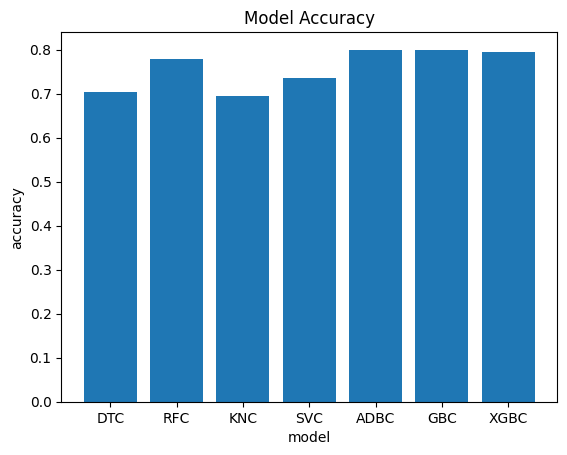

In [66]:
plt.bar(results.keys(),results.values())
plt.title("Model Accuracy")
plt.xlabel("model")
plt.ylabel("accuracy")

plt.show()

In [67]:
best_model_name=max(results,key=results.get)

print("best_model:",best_model_name)
print("accuracy:",results[best_model_name])

best_model: ADBC
accuracy: 0.7995


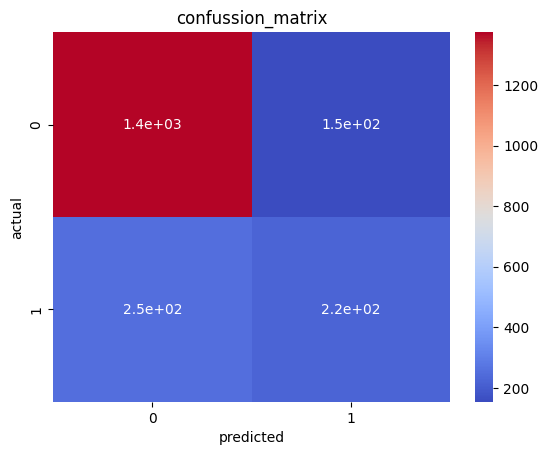

In [68]:
best_model=gbc_grid.best_estimator_

y_pred=best_model.predict(x_test_scaled)

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="coolwarm")

plt.title("confussion_matrix")
plt.xlabel("predicted")
plt.ylabel('actual')
plt.show()

# Deployment

In [69]:
import streamlit as st
import joblib

In [70]:
joblib.dump(gbc_grid,r'st_dropout.pkl')
joblib.dump(le_gender,r'lb.pkl')
joblib.dump(le_internet,r'lb1.pkl')
joblib.dump(le_partime,r'lb2.pkl')
joblib.dump(le_scholar,r'lb3.pkl')
joblib.dump(le_sem,r'lb4.pkl')
joblib.dump(le_dept,r'lb5.pkl')
joblib.dump(le_pnt_edu,r'lb6.pkl')
joblib.dump(scaler,r'st.pkl')

['st.pkl']

In [71]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [72]:
data

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
